<a href="https://colab.research.google.com/github/vkrafted21/stressprediciton-model/blob/main/periods.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving periods.xlsx to periods.xlsx


In [ ]:
import pandas as pd
import numpy as np

df=pd.read_excel('periods.xlsx')


In [ ]:
df.shape

(897, 3)

In [ ]:
df.head()


,period_flow,expected_vs_actual_date_difference,period_stress
0,-1,5,3.980118
1,0,1,1.000000
2,1,5,1.578977
3,-1,-1,4.838273
4,1,2,1.014375


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix,classification_report
from sklearn.preprocessing import StandardScaler

In [ ]:
X = df[['period_flow', 'expected_vs_actual_date_difference']]
y = df['period_stress']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

In [ ]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)


In [ ]:
rf.fit(X_train, y_train)


RandomForestRegressor(random_state=42)

In [ ]:
y_pred = rf.predict(X_test)


In [ ]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [ ]:

print(f"Mean Squared Error: {mse:.3f}")
print(f"R2 Score: {r2:.3f}")

Mean Squared Error: 0.274
R2 Score: 0.832


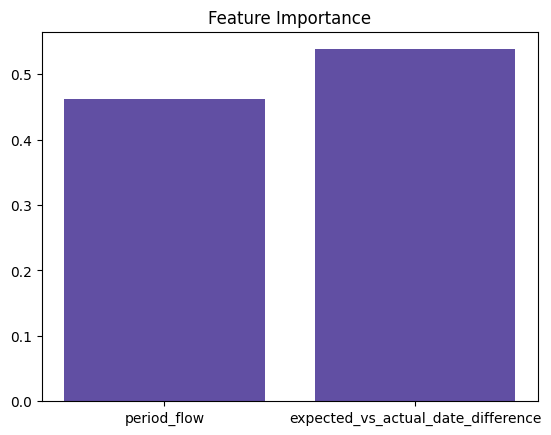

In [ ]:
importances = rf.feature_importances_
feature_names = X.columns
plt.bar(feature_names, importances,color='#614FA3')
plt.title("Feature Importance")
plt.show()

In [ ]:
new_data = pd.DataFrame({'period_flow':[1], 'expected_vs_actual_date_difference':[2]})
predicted_stress = rf.predict(new_data)
print(f"Predicted Period Stress: {predicted_stress[0]:.3f}")

Predicted Period Stress: 1.180


In [ ]:
tolerance = 0.5
accuracy = ((abs(y_test - y_pred) <= tolerance).sum()) / len(y_test)
print(f"Accuracy within ±{tolerance}: {accuracy*100:.2f}%")


Accuracy within ±0.5: 65.56%


In [ ]:
import joblib
joblib.dump(rf, "classifier.joblib")


['classifier.joblib']

In [ ]:
import joblib

# Save your trained Random Forest model
joblib.dump(rf, "classifier.joblib")

print("✅ Classifier model saved as classifier.joblib")



✅ Classifier model saved as classifier.joblib


In [ ]:
from google.colab import files
files.download("classifier.joblib")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>